# Mixup Augmentation — Capuchinbird Calls

This notebook tests **mixup / between-class mixing** on the Capuchinbird
dataset before wiring it into the training pipeline.

Mixup blends two clips and their labels:

```
mixed_wav   = lambda * wav_a       + (1 - lambda) * wav_b
mixed_label = lambda * label_a     + (1 - lambda) * label_b
```

where `lambda ~ Beta(alpha, alpha)`.

Here we mix a **Capuchin call** clip (label = 1) with a **Not-Capuchin /
background noise** clip (label = 0), so `mixed_label` becomes a soft value
between 0 and 1 — a partial-call training example.

This notebook uses `librosa` + `matplotlib` + `IPython.display` for quick,
interactive exploration (listening + plotting). It's deliberately separate
from the production `tf.data` pipeline — once you're happy with how mixup
behaves here, port the parameters over to a `tf.data`-based implementation
(pure-TensorFlow version, safe to drop into a `.map()` call, is available on
request).

**Requirements:** `pip install librosa soundfile matplotlib` (if not already
in `requirements.txt`).

In [1]:
import os
import glob
import random

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)


## Config

Paths below assume this notebook lives in `research/` and data lives in
`data/raw/...`, matching the project layout. Adjust `DATA_ROOT` if your
Jupyter kernel's working directory differs.

In [2]:
# Paths are relative to this notebook's location: research/
DATA_ROOT = os.path.join("..", "data", "raw")
CAPUCHIN_DIR = os.path.join(DATA_ROOT, "Parsed_Capuchinbird_Clips")
NOT_CAPUCHIN_DIR = os.path.join(DATA_ROOT, "Parsed_Not_Capuchinbird_Clips")

SAMPLE_RATE = 24000          # target sample rate -- match your pipeline's rate
CLIP_DURATION_SEC = 3.0      # target clip length -- match your pipeline's clip length
CLIP_LEN_SAMPLES = int(SAMPLE_RATE * CLIP_DURATION_SEC)

MIXUP_ALPHA = 0.4            # Beta(alpha, alpha) shape parameter for lambda

assert os.path.isdir(CAPUCHIN_DIR), f"Not found: {CAPUCHIN_DIR} -- update DATA_ROOT above"
assert os.path.isdir(NOT_CAPUCHIN_DIR), f"Not found: {NOT_CAPUCHIN_DIR} -- update DATA_ROOT above"


## Data loading helpers

In [3]:
def load_wav(path, sr=SAMPLE_RATE):
    """Load a wav file, resample to `sr`, force mono, return float32 numpy
    array in [-1, 1]. Swap for your existing loader in features/ if you
    have one, to keep this notebook consistent with the training pipeline."""
    wav, _ = librosa.load(path, sr=sr, mono=True)
    return wav.astype(np.float32)


def pad_or_trim(wav, target_len=CLIP_LEN_SAMPLES):
    """Force a waveform to exactly `target_len` samples: zero-pad short
    clips, center-crop long ones, so mixup always operates on matching
    shapes."""
    if len(wav) >= target_len:
        start = (len(wav) - target_len) // 2
        return wav[start:start + target_len]
    pad_total = target_len - len(wav)
    pad_left = pad_total // 2
    pad_right = pad_total - pad_left
    return np.pad(wav, (pad_left, pad_right), mode="constant")


def list_clips(directory):
    return sorted(glob.glob(os.path.join(directory, "*.wav")))


In [4]:
capuchin_files = list_clips(CAPUCHIN_DIR)
not_capuchin_files = list_clips(NOT_CAPUCHIN_DIR)

print(f"Capuchin call clips:        {len(capuchin_files)}")
print(f"Not-Capuchin (noise) clips: {len(not_capuchin_files)}")
assert capuchin_files and not_capuchin_files, "No .wav files found -- check DATA_ROOT."


Capuchin call clips:        217
Not-Capuchin (noise) clips: 210


## Spectrogram helper

In [5]:
def compute_spectrogram(wav, sr=SAMPLE_RATE, n_fft=512, hop_length=160, n_mels=64):
    """Log-mel spectrogram, dB scale. Swap this out for
    features/mel_spectogram_generator.py's logic to stay consistent with
    the rest of the pipeline."""
    mel = librosa.feature.melspectrogram(
        y=wav, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
    )
    return librosa.power_to_db(mel, ref=np.max)


## Mixup functions

In [6]:
def sample_lambda(alpha=MIXUP_ALPHA):
    """lambda ~ Beta(alpha, alpha). alpha -> 0 gives mild mixing
    (lambda near 0 or 1, i.e. mostly one clip); alpha = 1 gives uniform
    mixing strength across [0, 1]."""
    return float(np.random.beta(alpha, alpha))


def mixup_waveforms(wav_a, wav_b, lam):
    """Linearly blend two equal-length waveforms."""
    assert len(wav_a) == len(wav_b), "Pad/trim both clips to the same length first."
    return lam * wav_a + (1.0 - lam) * wav_b


def mixup_label(label_a, label_b, lam):
    """Soft label for the mixed clip, e.g. label_a=1 (capuchin), label_b=0 (not)."""
    return lam * label_a + (1.0 - lam) * label_b


## Visualization functions

In [7]:
def plot_waveform_comparison(wav_a, wav_b, wav_mixed, sr=SAMPLE_RATE, lam=None,
                              labels=("A: Capuchin", "B: Not Capuchin", "Mixed")):
    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True, sharey=True)
    t = np.arange(len(wav_a)) / sr
    for ax, wav, label in zip(axes, [wav_a, wav_b, wav_mixed], labels):
        ax.plot(t, wav, linewidth=0.6)
        ax.set_ylabel("Amplitude")
        title = label
        if lam is not None and label == labels[2]:
            title = f"{label} (\u03bb={lam:.2f})"
        ax.set_title(title)
    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()


In [8]:
def plot_spectrogram_comparison(spec_a, spec_b, spec_mixed, sr=SAMPLE_RATE, hop_length=160,
                                 lam=None, labels=("A: Capuchin", "B: Not Capuchin", "Mixed")):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    img = None
    for ax, spec, label in zip(axes, [spec_a, spec_b, spec_mixed], labels):
        img = librosa.display.specshow(
            spec, sr=sr, hop_length=hop_length, x_axis="time", y_axis="mel",
            ax=ax, cmap="magma"
        )
        title = label
        if lam is not None and label == labels[2]:
            title = f"{label} (\u03bb={lam:.2f})"
        ax.set_title(title)
    fig.colorbar(img, ax=axes, format="%+2.0f dB", fraction=0.02)
    plt.show()


In [9]:
def play_audio_comparison(wav_a, wav_b, wav_mixed, sr=SAMPLE_RATE, lam=None):
    print("A - Capuchin call:")
    ipd.display(ipd.Audio(wav_a, rate=sr))

    print("B - Not Capuchin (background/noise):")
    ipd.display(ipd.Audio(wav_b, rate=sr))

    label = "Mixed"
    if lam is not None:
        label = f"Mixed (\u03bb={lam:.2f}, soft label={lam:.2f})"
    print(label + ":")
    ipd.display(ipd.Audio(wav_mixed, rate=sr))


## Choosing alpha

`lambda` is drawn from `Beta(alpha, alpha)`. Low alpha (~0.2) mostly gives
mild blends; alpha = 1 gives uniformly strong blends. Run this to see the
shape before picking a value for `MIXUP_ALPHA` above.

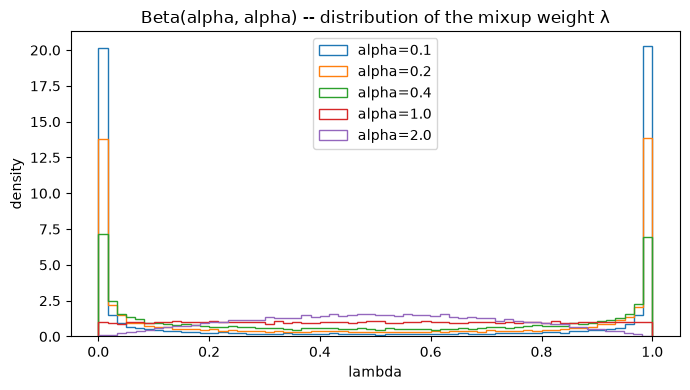

In [10]:
def plot_beta_distribution(alphas=(0.1, 0.2, 0.4, 1.0, 2.0), n_samples=20000):
    fig, ax = plt.subplots(figsize=(7, 4))
    for a in alphas:
        samples = np.random.beta(a, a, size=n_samples)
        ax.hist(samples, bins=60, histtype="step", density=True, label=f"alpha={a}")
    ax.set_xlabel("lambda")
    ax.set_ylabel("density")
    ax.set_title("Beta(alpha, alpha) -- distribution of the mixup weight \u03bb")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_beta_distribution()


## Run a mixup demo

Picks one random Capuchin clip and one random Not-Capuchin clip, mixes them
at a randomly sampled `lambda`, and reports the resulting soft label.

In [16]:
capuchin_path = random.choice(capuchin_files)
not_capuchin_path = random.choice(not_capuchin_files)

print("Capuchin clip:", capuchin_path)
print("Not-Capuchin clip:", not_capuchin_path)

wav_a = pad_or_trim(load_wav(capuchin_path))
wav_b = pad_or_trim(load_wav(not_capuchin_path))

lam = sample_lambda(MIXUP_ALPHA)
wav_mixed = mixup_waveforms(wav_a, wav_b, lam)
soft_label = mixup_label(1.0, 0.0, lam)

print(f"\nSampled lambda: {lam:.3f}")
print(f"Mixed clip soft label (1=Capuchin, 0=Not): {soft_label:.3f}")


Capuchin clip: ..\data\raw\Parsed_Capuchinbird_Clips\XC22397-4.wav
Not-Capuchin clip: ..\data\raw\Parsed_Not_Capuchinbird_Clips\cricket-sounds-for-sleep-43.wav

Sampled lambda: 0.190
Mixed clip soft label (1=Capuchin, 0=Not): 0.190


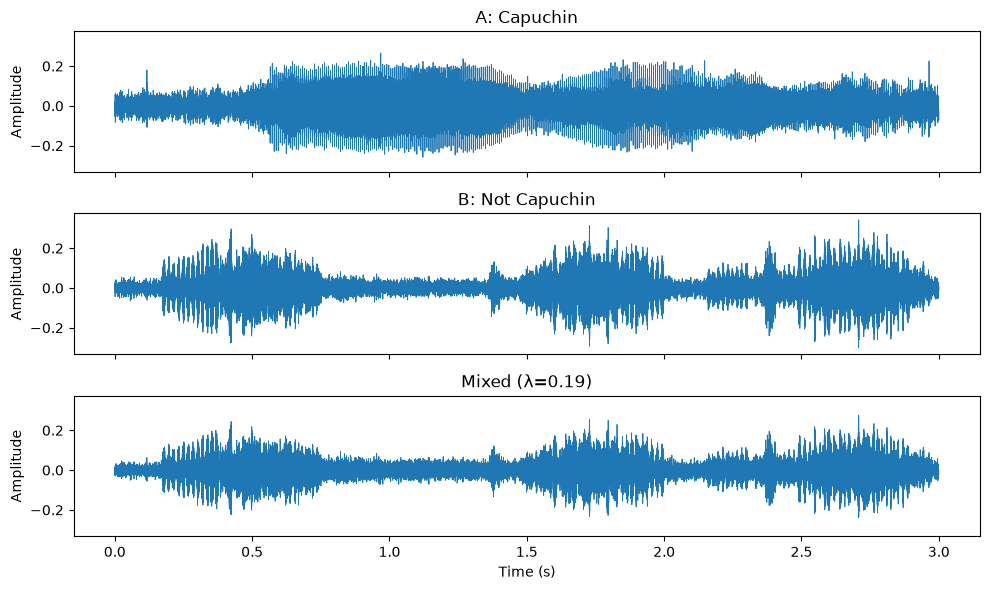

In [17]:
plot_waveform_comparison(wav_a, wav_b, wav_mixed, lam=lam)


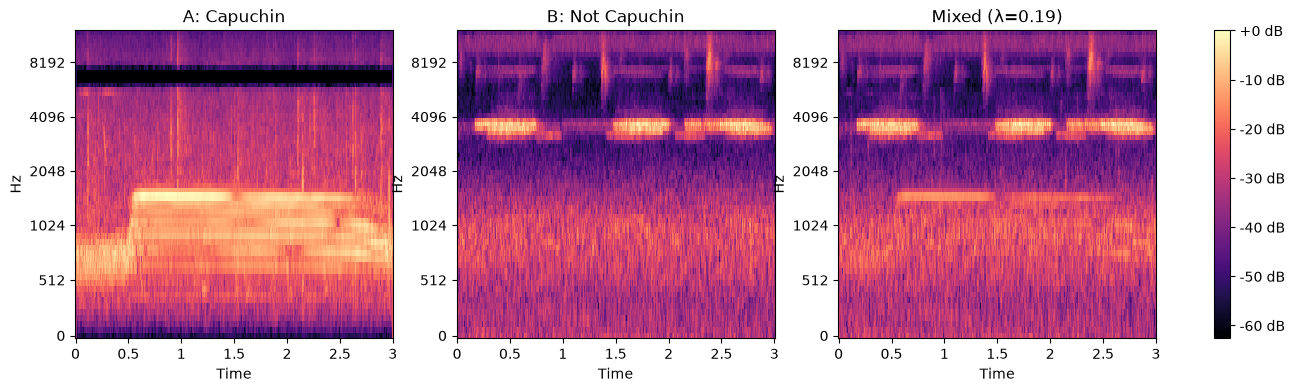

In [18]:
spec_a = compute_spectrogram(wav_a)
spec_b = compute_spectrogram(wav_b)
spec_mixed = compute_spectrogram(wav_mixed)

plot_spectrogram_comparison(spec_a, spec_b, spec_mixed, lam=lam)


In [19]:
play_audio_comparison(wav_a, wav_b, wav_mixed, lam=lam)


A - Capuchin call:


B - Not Capuchin (background/noise):


Mixed (λ=0.19, soft label=0.19):


## Explore multiple mixing strengths on the same pair

Reuses `wav_a` / `wav_b` from above and sweeps `lambda` across a range, so
you can see (and hear) how the blend changes from mostly-noise to
mostly-call.

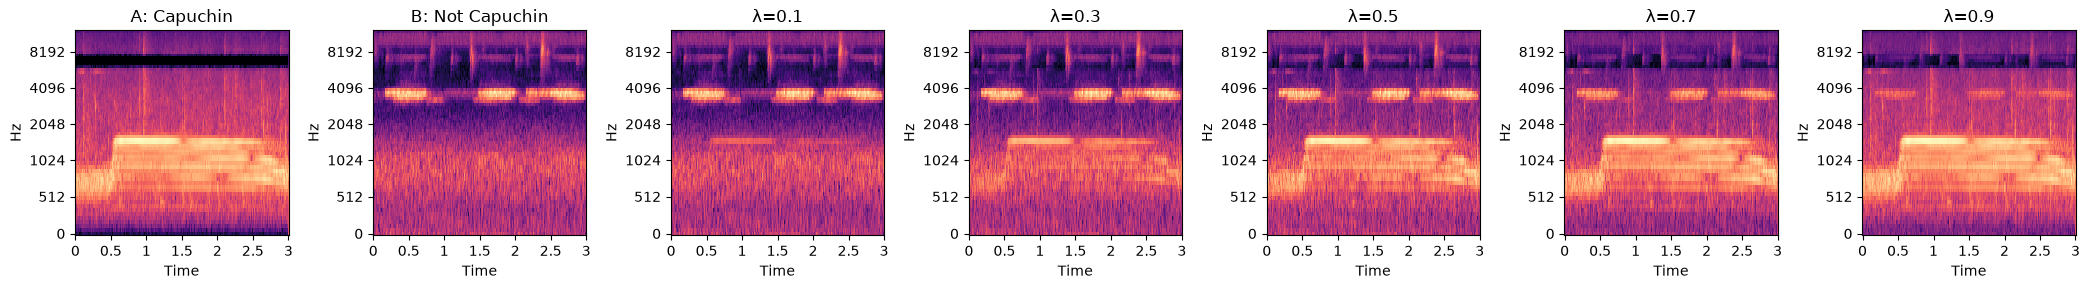

In [20]:
lambdas_to_try = [0.1, 0.3, 0.5, 0.7, 0.9]

fig, axes = plt.subplots(1, len(lambdas_to_try) + 2, figsize=(3 * (len(lambdas_to_try) + 2), 3))

librosa.display.specshow(spec_a, sr=SAMPLE_RATE, hop_length=160, x_axis="time", y_axis="mel",
                          ax=axes[0], cmap="magma")
axes[0].set_title("A: Capuchin")

librosa.display.specshow(spec_b, sr=SAMPLE_RATE, hop_length=160, x_axis="time", y_axis="mel",
                          ax=axes[1], cmap="magma")
axes[1].set_title("B: Not Capuchin")

mixed_clips = {}
for ax, lam_i in zip(axes[2:], lambdas_to_try):
    mixed_i = mixup_waveforms(wav_a, wav_b, lam_i)
    mixed_clips[lam_i] = mixed_i
    spec_i = compute_spectrogram(mixed_i)
    librosa.display.specshow(spec_i, sr=SAMPLE_RATE, hop_length=160, x_axis="time", y_axis="mel",
                              ax=ax, cmap="magma")
    ax.set_title(f"\u03bb={lam_i}")

plt.tight_layout()
plt.show()


In [21]:
for lam_i in lambdas_to_try:
    print(f"\u03bb={lam_i} (soft label={lam_i}):")
    ipd.display(ipd.Audio(mixed_clips[lam_i], rate=SAMPLE_RATE))


λ=0.1 (soft label=0.1):


λ=0.3 (soft label=0.3):


λ=0.5 (soft label=0.5):


λ=0.7 (soft label=0.7):


λ=0.9 (soft label=0.9):


## Next steps

Once `MIXUP_ALPHA` and the mixing behavior look right here:

- Port `sample_lambda` / `mixup_waveforms` / `mixup_label` into a
  `tf.data`-friendly version that mixes whole **batches** using pure
  TensorFlow ops (`tf.random.gamma` for the Beta draw, `tf.gather` for
  batch shuffling), so it can run inside `.map()` during training.
- Keep this notebook around as a quick sanity check whenever you change
  `alpha`, clip length, or the spectrogram settings.
- Consider applying mixup for most of training, then fine-tuning the last
  few epochs on clean (unmixed) clips.